# Europarl EN to FR - Overall Analysis


In [1]:
!pip install -q sacrebleu pandas

In [2]:
import os, json
import numpy as np
import pandas as pd
import sacrebleu
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')


In [3]:
DRIVE_BASE_DIR = '/content/drive/MyDrive/UB Reading Supp./Deep Learning/Group Project/model_assets'
DRIVE_OK = False
try:
    from google.colab import drive
    drive.mount('/content/drive', force_remount=False)
    DRIVE_OK = os.path.isdir(DRIVE_BASE_DIR)
    print(f"Drive mounted. Reading from {DRIVE_BASE_DIR}/m_training_<run_id>/")
except ImportError:
    print('Not running on Colab — will fall back to local files (metrics_<run_id>.json, etc.)')

Mounted at /content/drive
Drive mounted. Reading from /content/drive/MyDrive/UB Reading Supp./Deep Learning/Group Project/model_assets/m_training_<run_id>/


In [4]:
def load_run_metrics(run_id, drive_base_dir=DRIVE_BASE_DIR, drive_ok=DRIVE_OK):
    candidates = []
    if drive_ok:
        candidates.append(os.path.join(drive_base_dir, f'm_training_{run_id}', 'metrics.json'))
    candidates.append(f'metrics_{run_id}.json')
    for path in candidates:
        if os.path.exists(path):
            with open(path) as f:
                return json.load(f)
    raise FileNotFoundError(f"metrics for run_id={run_id} not found in {candidates}")

def load_run_predictions(run_id, split, drive_base_dir=DRIVE_BASE_DIR, drive_ok=DRIVE_OK):
    candidates = []
    if drive_ok:
        candidates.append(os.path.join(drive_base_dir, f'm_training_{run_id}', f'{split}_predictions.csv'))
    candidates.append(f'{split}_predictions_{run_id}.csv')
    for path in candidates:
        if os.path.exists(path):
            return pd.read_csv(path)
    raise FileNotFoundError(f"{split}_predictions for run_id={run_id} not found in {candidates}")

print('Loaders defined: load_run_metrics, load_run_predictions')

Loaders defined: load_run_metrics, load_run_predictions


In [6]:
ALL_RUNS = ['200k', '500k', '200k_s13', '200k_s99', 'lstm']

metrics_dict = {}
for rid in ALL_RUNS:
    try:
        metrics_dict[rid] = load_run_metrics(rid)
        m = metrics_dict[rid]
        print(f"  loaded {rid:<10}  arch={m['arch']:<11}  val_bleu={m['val_bleu']:5.2f}  test_bleu={m['test_bleu']:5.2f}")
    except FileNotFoundError:
        print(f"  skipping {rid:<10}  (metrics.json not found in Drive nor locally)")

print(f"\nLoaded {len(metrics_dict)} exps/runs.")
if not metrics_dict:
    print("\nNothing to analyze. Run at least one training notebook's *Save artifacts* cell first, "
          "then re-run cells 4 + 5 here.")

  loaded 200k        arch=transformer  val_bleu=30.34  test_bleu=30.61
  loaded 500k        arch=transformer  val_bleu=33.96  test_bleu=34.56
  loaded 200k_s13    arch=transformer  val_bleu=30.22  test_bleu=30.17
  loaded 200k_s99    arch=transformer  val_bleu=30.49  test_bleu=30.52
  loaded lstm        arch=lstm         val_bleu= 6.67  test_bleu= 6.59

Loaded 5 exps/runs.


### Summary table

In [6]:
rows = []
for rid, m in metrics_dict.items():
    rows.append({
        'run_id':        rid,
        'arch':          m['arch'],
        'max_lines':     m['config']['max_lines'],
        'seed':          m['config']['seed'],
        'n_train':       m['n_pairs']['train'],
        'n_params_M':    round(m['config'].get('n_params', 0) / 1e6, 1),
        'epochs':        m['config']['epochs'],
        'best_epoch':    m['best_epoch'],
        'best_val_loss': round(m['best_val_loss'], 4),
        'val_bleu':      round(m['val_bleu'], 2),
        'test_bleu':     round(m['test_bleu'], 2),
        'total_min':     round(sum(m.get('epoch_times_s', [])) / 60, 1),
    })
summary_df = pd.DataFrame(rows).sort_values(['arch', 'max_lines', 'seed']).reset_index(drop=True) \
             if rows else pd.DataFrame()
if len(summary_df):
    print(summary_df.to_string(index=False))
    summary_df.to_csv('analysis_summary.csv', index=False)
    print('\n(also written to analysis_summary.csv)')
else:
    print('Empty — no runs loaded.')

  run_id        arch  max_lines  seed  n_train  n_params_M  epochs  best_epoch  best_val_loss  val_bleu  test_bleu  total_min
    lstm        lstm     200000    42   174289        26.3      35          32         5.2104      6.67       6.59      269.5
200k_s13 transformer     200000    13   174289        52.3      15          11         2.6535     30.22      30.17       21.2
    200k transformer     200000    42   174289        52.3      15          13         2.6490     30.34      30.61       21.3
200k_s99 transformer     200000    99   174289        52.3      15          14         2.6460     30.49      30.52       21.1
    500k transformer     500000    42   444967        52.3      15          15         2.4182     33.96      34.56       53.5

(also written to analysis_summary.csv)


### Training-curve

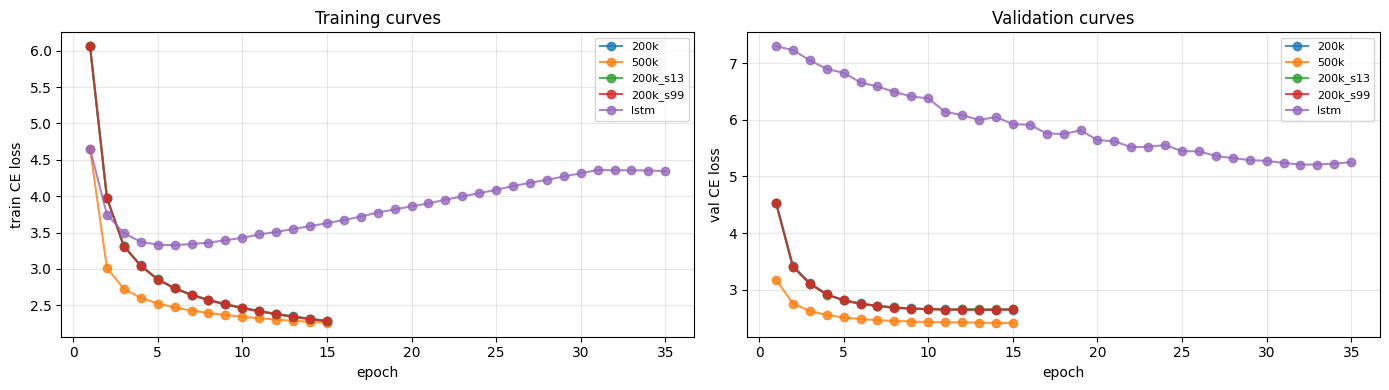

In [7]:
if metrics_dict:
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    for rid, m in metrics_dict.items():
        epochs = list(range(1, len(m['val_curve']) + 1))
        axes[0].plot(epochs, m['train_curve'], marker='o', label=rid, alpha=0.8)
        axes[1].plot(epochs, m['val_curve'],   marker='o', label=rid, alpha=0.8)
    axes[0].set_xlabel('epoch'); axes[0].set_ylabel('train CE loss'); axes[0].set_title('Training curves')
    axes[1].set_xlabel('epoch'); axes[1].set_ylabel('val CE loss');   axes[1].set_title('Validation curves')
    for ax in axes:
        ax.grid(alpha=0.3); ax.legend(fontsize=8)
    plt.tight_layout()
    plt.savefig('analysis_curves_overlay.png', dpi=120, bbox_inches='tight')
    plt.show()
else:
    print('Nothing to plot.')

### Comparing Transformer Runs/Exps

In [8]:
seed_runs = {rid: m for rid, m in metrics_dict.items()
             if m['arch'] == 'transformer' and m['config']['max_lines'] == 200_000}

if len(seed_runs) >= 2:
    val_bleus  = np.array([m['val_bleu']  for m in seed_runs.values()])
    test_bleus = np.array([m['test_bleu'] for m in seed_runs.values()])
    seeds      = [m['config']['seed'] for m in seed_runs.values()]
    print(f"Transformer 200k multi-seed (n={len(seed_runs)}, seeds={seeds}):")
    print(f"  Val  BLEU: {val_bleus.mean():.2f} ± {val_bleus.std(ddof=1):.2f}    "
          f"(min {val_bleus.min():.2f}, max {val_bleus.max():.2f})")
    print(f"  Test BLEU: {test_bleus.mean():.2f} ± {test_bleus.std(ddof=1):.2f}    "
          f"(min {test_bleus.min():.2f}, max {test_bleus.max():.2f})")
    print('\nFormat: "BLEU = <mean> ± <std> over n=<n> seeds".')
elif len(seed_runs) == 1:
    rid = next(iter(seed_runs))
    print(f"Only 1 seed loaded ({rid}, seed={seed_runs[rid]['config']['seed']}). "
          f"Run Run C and Run D in Europarl_Training_Transformer.ipynb to get a CI.")
else:
    print('No 200k Transformer runs loaded.')

Transformer 200k multi-seed (n=3, seeds=[42, 13, 99]):
  Val  BLEU: 30.35 ± 0.14    (min 30.22, max 30.49)
  Test BLEU: 30.43 ± 0.23    (min 30.17, max 30.61)

Format: "BLEU = <mean> ± <std> over n=<n> seeds".


### BLEU by source length

Test BLEU by source-length bucket (English words):

run_id           200k  200k_s13  200k_s99   500k   lstm
src_len_bucket                                         
(0, 5]          57.61     55.39     55.97  61.79  34.86
(10, 15]        31.05     30.93     31.71  34.24   8.87
(15, 20]        30.38     28.54     29.38  35.26   7.06
(20, 30]        29.57     29.63     29.82  33.94   5.47
(30, 50]        30.59     30.19     30.28  34.33   5.33
(5, 10]         34.41     34.32     35.49  35.77  13.69


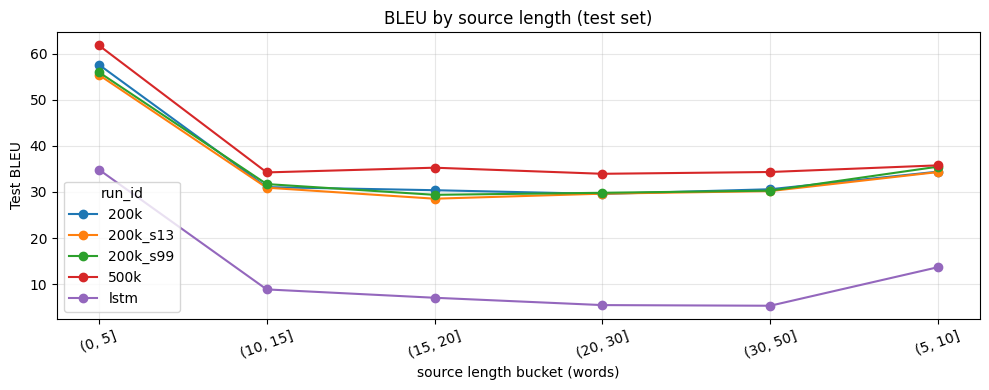

In [11]:
LENGTH_BINS = [0, 5, 10, 15, 20, 30, 50, 200]

len_rows = []
for rid in metrics_dict:
    try:
        df = load_run_predictions(rid, 'test')
    except FileNotFoundError:
        print(f"  no test_predictions for {rid}, skipping")
        continue
    df['src_len'] = df['src'].str.split().str.len()
    df['bucket'] = pd.cut(df['src_len'], bins=LENGTH_BINS)
    for bucket, group in df.groupby('bucket', observed=True):
        if len(group) == 0: continue
        bleu = sacrebleu.corpus_bleu(group['hyp'].tolist(), [group['ref'].tolist()]).score
        len_rows.append({'run_id': rid, 'src_len_bucket': str(bucket), 'n': len(group), 'bleu': round(bleu, 2)})

if len_rows:
    length_df = pd.DataFrame(len_rows)
    pivot = length_df.pivot(index='src_len_bucket', columns='run_id', values='bleu')
    print('Test BLEU by source-length bucket (English words):\n')
    print(pivot.to_string())
    pivot.to_csv('analysis_bleu_by_length.csv')
    

    # Bonus: plot the buckets
    fig, ax = plt.subplots(figsize=(10, 4))
    pivot.plot(marker='o', ax=ax)
    ax.set_ylabel('Test BLEU'); ax.set_xlabel('source length bucket (words)')
    ax.set_title('BLEU by source length (test set)')
    ax.grid(alpha=0.3)
    plt.xticks(rotation=20)
    plt.tight_layout()
    plt.savefig('analysis_bleu_by_length.png', dpi=120, bbox_inches='tight')
    plt.show()
else:
    print('No predictions loaded.')

### Qual. Pairwise diff

In [12]:
RUN_A = '200k'   # Transformer 200k
RUN_B = 'lstm'   # LSTM 200k
TOP_K = 8

if RUN_A in metrics_dict and RUN_B in metrics_dict:
    df_a = load_run_predictions(RUN_A, 'test')
    df_b = load_run_predictions(RUN_B, 'test')
    cmp = df_a.merge(df_b, on=['idx', 'src', 'ref'], suffixes=(f'_{RUN_A}', f'_{RUN_B}'))
    cmp['disagreement'] = (cmp[f'hyp_{RUN_A}'].fillna('').str.len()
                            - cmp[f'hyp_{RUN_B}'].fillna('').str.len()).abs() \
                          + cmp.apply(lambda r: 0 if str(r[f'hyp_{RUN_A}']) == str(r[f'hyp_{RUN_B}']) else 1, axis=1) * 50
    top_diffs = cmp.sort_values('disagreement', ascending=False).head(TOP_K)
    print(f"Top-{TOP_K} sentences where {RUN_A} and {RUN_B} disagree most:\n")
    for _, r in top_diffs.iterrows():
        print(f"EN:  {r['src']}")
        print(f"REF: {r['ref']}")
        print(f"  [{RUN_A}] {r[f'hyp_{RUN_A}']}")
        print(f"  [{RUN_B}] {r[f'hyp_{RUN_B}']}")
        print()
else:
    have = sorted(metrics_dict.keys())
    print(f"Need both {RUN_A} and {RUN_B} loaded. Currently loaded: {have}")

Top-8 sentences where 200k and lstm disagree most:

EN:  however, we must be clear about a number of things: structures in candidate countries vary considerably; in fact they could not vary more, which is why everything we do must be geared to the structures which currently exist in the individual member states.
REF: cependant, certains points méritent quelques éclaircissements : la structure des pays candidats à l'adhésion présente tellement de divergences, il ne pourrait en réalité pas être plus différencié.
  [200k] nous devons toutefois être clairs à propos d'un certain nombre de choses : les structures des pays candidats sont très différentes ; elles ne peuvent en effet pas être plus diverses.
  [lstm] il faut structures structures structures structures structures structures structures structures structures structures structures structures structures structures structures structures structures structures structures structures structures structures structures structures structures 

### Per-sentence sentence-BLEU rankings

In [ ]:
RUN = '200k'   # which run to check
TOP_K = 5

if RUN in metrics_dict:
    df = load_run_predictions(RUN, 'test').copy()
    df['hyp']  = df['hyp'].fillna('')
    df['ref']  = df['ref'].fillna('')
    df['sentence_bleu'] = [
        sacrebleu.sentence_bleu(h, [r]).score for h, r in zip(df['hyp'], df['ref'])
    ]
    print(f"Worst {TOP_K} test sentences for run '{RUN}' (by sentence-BLEU):\n")
    worst = df.sort_values('sentence_bleu').head(TOP_K)
    for _, r in worst.iterrows():
        print(f"BLEU: {r['sentence_bleu']:.1f}")
        print(f"EN:   {r['src']}")
        print(f"REF:  {r['ref']}")
        print(f"HYP:  {r['hyp']}")
        print()
    print(f"\nBest {TOP_K} test sentences:\n")
    best = df.sort_values('sentence_bleu', ascending=False).head(TOP_K)
    for _, r in best.iterrows():
        print(f"BLEU: {r['sentence_bleu']:.1f}")
        print(f"EN:   {r['src']}")
        print(f"REF:  {r['ref']}")
        print(f"HYP:  {r['hyp']}")
        print()
else:
    print(f"Run '{RUN}' not loaded.")

Worst 5 test sentences for run '200k' (by sentence-BLEU):

BLEU: 0.0
EN:   this is completely unacceptable.
REF:  il ne peut en être ainsi !
HYP:  c'est tout à fait inacceptable.

BLEU: 0.0
EN:   that is unreasonable.
REF:  ce n'est pas juste !
HYP:  c'est déraisonnable.

BLEU: 0.0
EN:   life
REF:  life
HYP:  vie

BLEU: 0.0
EN:   it simply has not.
REF:  ce n'est pas le cas !
HYP:  il n'a rien d'autre.

BLEU: 1.7
EN:   now we find that britain' s solidarity extends across the atlantic and across the pacific ocean.
REF:  or, on découvre que les anglais sont solidaires de l' autre côté de l' océan atlantique, de l' autre côté de l' océan pacifique.
HYP:  nous constatons maintenant que la solidarité britannique s'étende de l'atlantique et de l'océan pacifiste.


Best 5 test sentences:

BLEU: 100.0
EN:   joint motion for a resolution on the floods in italy and spain
REF:  proposition de résolution commune sur les inondations en italie et en espagne
HYP:  proposition de résolution commune s